# Train Unified Graph-Mamba

All experiment parameters come from `configs/default.yaml`. The `run_name` field controls run-scoped paths: checkpoints go to `checkpoints/<run_name>/`, and graph/metrics outputs go to `output/<run_name>/`.

In [1]:
from pathlib import Path
import copy
import json
import sys

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'configs/default.yaml').exists():
    REPO_ROOT = Path('D:/TEMPO_GNN')

CONFIG_PATH = REPO_ROOT / 'configs/default.yaml'
sys.path.insert(0, str(REPO_ROOT / 'src'))

from graphmamba.config import load_config, resolve_run_paths

def make_repo_path(value):
    path = Path(value)
    return str(path if path.is_absolute() else REPO_ROOT / path)

config = copy.deepcopy(load_config(CONFIG_PATH))
config['paths']['checkpoint_root'] = make_repo_path(config['paths']['checkpoint_root'])
config['paths']['output_root'] = make_repo_path(config['paths']['output_root'])
run_paths = resolve_run_paths(config)

print(json.dumps({
    'config_path': str(CONFIG_PATH),
    'run_name': run_paths['run_name'],
    'date_range': [config['data']['start_date'], config['data']['end_date']],
    'lead_time': config['data'].get('lead_time', 0),
    'train_fraction': config['training']['train_fraction'],
    'val_fraction': config['training']['val_fraction'],
    'test_fraction': 1.0 - config['training']['train_fraction'] - config['training']['val_fraction'],
    'epochs': config['training']['epochs'],
    'batch_size': config['training']['batch_size'],
    'show_progress': config['training'].get('show_progress', True),
    'resume_training': config['training'].get('resume_training', False),
    'batch_log_interval': config['training'].get('batch_log_interval', 0),
    'device': config['training']['device'],
    'multi_gpu': config['training'].get('multi_gpu', 'off'),
    'gpu_min_free_memory_gb': config['training'].get('gpu_min_free_memory_gb', 0.0),
    'gpu_max_count': config['training'].get('gpu_max_count'),
    'checkpoint_dir': str(run_paths['checkpoint_dir']),
    'output_dir': str(run_paths['output_dir']),
    'graph_path': str(run_paths['graph_path']),
}, indent=2))

{
  "config_path": "D:/TEMPO_GNN/configs/default.yaml",
  "run_name": "test",
  "date_range": [
    "2023-07-01",
    "2024-06-30"
  ],
  "lead_time": 0,
  "train_fraction": 0.7,
  "val_fraction": 0.15,
  "test_fraction": 0.15000000000000005,
  "epochs": 50,
  "batch_size": 32,
  "show_progress": true,
  "resume_training": true,
  "batch_log_interval": 0,
  "device": "auto",
  "multi_gpu": true,
  "gpu_min_free_memory_gb": 20.0,
  "gpu_max_count": 4,
  "checkpoint_dir": "D:/TEMPO_GNN/checkpoints/test",
  "output_dir": "D:/TEMPO_GNN/output/test",
  "graph_path": "D:/TEMPO_GNN/output/test/unified_graph.npz"
}


In [2]:
from graphmamba.graph import build_unified_graph

graph_summary = build_unified_graph(
    tempo_dir=config['paths']['tempo_dir'],
    airnow_dir=config['paths']['airnow_dir'],
    graph_path=run_paths['graph_path'],
    start_date=config['data']['start_date'],
    end_date=config['data']['end_date'],
    local_context_k=config['data']['local_context_k'],
    station_neighbor_k=config['data']['station_neighbor_k'],
    tempo_neighbor_k=config['data']['tempo_neighbor_k'],
)
graph_summary

{'path': 'D:/TEMPO_GNN/output/test/unified_graph.npz',
 'num_nodes': 1124,
 'num_airnow': 191,
 'num_tempo': 933,
 'average_station_to_nearest_tempo_km': 0.8002516031265259,
 'adaptive_context_radius_km': 2.910886287689209,
 'edge_count': 7056}

In [ ]:
from graphmamba.data import TempoAirNowDataset, split_indices

dataset = TempoAirNowDataset(
    graph_path=run_paths['graph_path'],
    tempo_dir=config['paths']['tempo_dir'],
    airnow_dir=config['paths']['airnow_dir'],
    start_date=config['data']['start_date'],
    end_date=config['data']['end_date'],
    context_steps=config['data']['context_steps'],
    max_time_snap_hours=config['data']['max_time_snap_hours'],
    max_column=config['data']['max_column'],
    min_valid_targets=config['data']['min_valid_targets'],
    lead_time=config['data'].get('lead_time', 0),
    tempo_variable=config['data'].get('tempo_variable', 'product/vertical_column_troposphere'),
    tempo_quality_variable=config['data'].get('tempo_quality_variable', 'product/main_data_quality_flag'),
    tempo_cloud_variable=config['data'].get('tempo_cloud_variable', 'support_data/eff_cloud_fraction'),
    tempo_quality_flag_valid=config['data'].get('tempo_quality_flag_valid', 0),
    tempo_cloud_fraction_max=config['data'].get('tempo_cloud_fraction_max', 0.2),
)
train_idx, val_idx, test_idx = split_indices(
    len(dataset),
    config['training']['train_fraction'],
    config['training']['val_fraction'],
)
print(json.dumps({
    'aligned_windows': len(dataset),
    'lead_time': dataset.lead_time,
    'train_windows': int(len(train_idx)),
    'val_windows': int(len(val_idx)),
    'test_windows': int(len(test_idx)),
}, indent=2))

In [4]:
from graphmamba.train import train

result = train(config)
print(json.dumps({
    'best_model': result['best_model'],
    'last_model': result['last_model'],
    'output_dir': result['output_dir'],
    'resume_training': result['resume_training'],
    'lead_time': result['lead_time'],
    'device': result['device'],
    'device_ids': result['device_ids'],
    'test': result['test'],
}, indent=2))

{
  "multi_gpu": true,
  "device_ids": [
    0,
    1,
    2,
    3
  ]
}
{
  "resume_training": true,
  "checkpoint_path": "D:/TEMPO_GNN/checkpoints/test/last_model.pt",
  "checkpoint_epoch": 46,
  "start_epoch": 47,
  "epochs": 50,
  "lead_time": 0.0
}


Training Epoch 47/50:   1%|          | 1/81 [01:46<2:22:35, 106.94s/batch, loss=0.138, lr=0.0003]/mnt/data2/kyo/.mamba/envs/Prithvi/lib/python3.10/site-packages/torch/nn/modules/linear.py:134: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:270.)
  return F.linear(input, self.weight, self.bias)
Validation Epoch: 100%|██████████| 18/18 [20:08<00:00, 67.13s/batch]


{"epoch": 47, "train_loss": 0.12832153340180716, "val_rmse": 4.843471527099609, "val_r2": 0.4420163631439209, "val_abs_error_delta_t_corr": 0.1253858208656311, "val_abs_error_nearest_tempo_distance_corr": 0.022854468518192443, "val_samples": 549, "val_observations": 94514}


Validation Epoch: 100%|██████████| 18/18 [20:13<00:00, 67.42s/batch]


{"epoch": 48, "train_loss": 0.12635560306134047, "val_rmse": 4.7093071937561035, "val_r2": 0.4725005626678467, "val_abs_error_delta_t_corr": 0.12600375711917877, "val_abs_error_nearest_tempo_distance_corr": 0.019825369938194278, "val_samples": 549, "val_observations": 94514}


...

{"epoch": 49, "train_loss": 0.12594557737494694, "val_rmse": 4.720995903015137, "val_r2": 0.4698787331581116, "val_abs_error_delta_t_corr": 0.12949177622795105, "val_abs_error_nearest_tempo_distance_corr": 0.01783690817873664, "val_samples": 549, "val_observations": 94514}


Validation Epoch: 100%|██████████| 18/18 [20:11<00:00, 67.28s/batch]


{"epoch": 50, "train_loss": 0.12585384711439226, "val_rmse": 4.945291996002197, "val_r2": 0.41830968856811523, "val_abs_error_delta_t_corr": 0.1378205269575119, "val_abs_error_nearest_tempo_distance_corr": 0.016135557901922788, "val_samples": 549, "val_observations": 94514}


Test Epoch: 100%|██████████| 18/18 [20:42<00:00, 69.04s/batch]


{
  "best_model": "D:/TEMPO_GNN/checkpoints/test/best_model.pt",
  "last_model": "D:/TEMPO_GNN/checkpoints/test/last_model.pt",
  "output_dir": "D:/TEMPO_GNN/output/test",
  "resume_training": true,
  "lead_time": 0.0,
  "device": "cuda:0",
  "device_ids": [
    0,
    1,
    2,
    3
  ],
  "test": {
    "rmse": 4.017939567565918,
    "r2": 0.5223016738891602,
    "abs_error_delta_t_corr": 0.15506325662136078,
    "abs_error_nearest_tempo_distance_corr": 0.008056497377843272,
    "samples": 551,
    "observations": 96662
  }
}


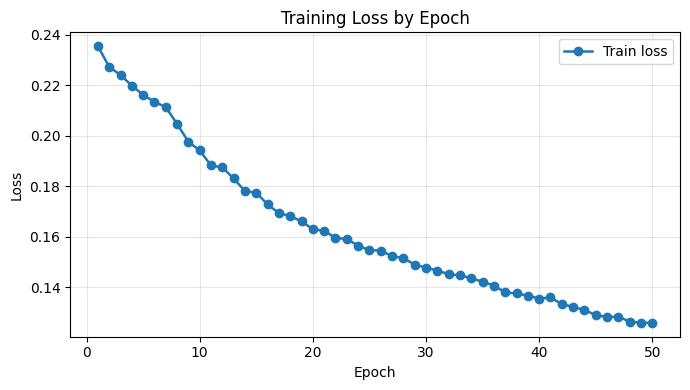

Saved loss curve: D:/TEMPO_GNN/output/test/loss_curve.png


,epoch,train_loss,val_rmse,val_r2,val_abs_error_delta_t_corr,val_abs_error_nearest_tempo_distance_corr,val_samples,val_observations
45,46,0.128180,5.099491,0.381469,0.130663,0.022966,549,94514
46,47,0.128322,4.843472,0.442016,0.125386,0.022854,549,94514
47,48,0.126356,4.709307,0.472501,0.126004,0.019825,549,94514
48,49,0.125946,4.720996,0.469879,0.129492,0.017837,549,94514
49,50,0.125854,4.945292,0.418310,0.137821,0.016136,549,94514


In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

history = pd.DataFrame(result['history'])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history['epoch'], history['train_loss'], marker='o', linewidth=1.8, label='Train loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss by Epoch')
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print(f"Saved loss curve: {result['loss_plot']}")
history.tail()